## Email Spam Detection — Data Preparation 

Pipeline steps:
1. Load `Spam.csv` (already has column headers)
2. Exploratory Data Analysis
3. Duplicate removal
4. Missing value check
5. Outlier analysis (no capping — extreme values are genuine spam signals)
6. Feature Engineering — spam/ham clusters, char scores, binary presence, word diversity


In [15]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from imblearn.over_sampling import SMOTE
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', 80)
plt.rcParams['figure.figsize'] = [13, 5]
sns.set_style('whitegrid')
print('Libraries loaded.')

Libraries loaded.


## 1. Load Dataset — Spam.csv

In [16]:
df = pd.read_csv('Spam.csv')
TARGET = 'spam'
features = [c for c in df.columns if c != TARGET]

print(f'Dataset loaded: {df.shape[0]} rows, {df.shape[1]} columns')
print(f'Features: {len(features)} | Target: {TARGET}')
display(df.head())

Dataset loaded: 4601 rows, 58 columns
Features: 57 | Target: spam


,word_freq_make,word_freq_address,word_freq_all,word_freq_3d,word_freq_our,word_freq_over,word_freq_remove,word_freq_internet,word_freq_order,word_freq_mail,word_freq_receive,word_freq_will,word_freq_people,word_freq_report,word_freq_addresses,word_freq_free,word_freq_business,word_freq_email,word_freq_you,word_freq_credit,word_freq_your,word_freq_font,word_freq_000,word_freq_money,word_freq_hp,word_freq_hpl,word_freq_george,word_freq_650,word_freq_lab,word_freq_labs,word_freq_telnet,word_freq_857,word_freq_data,word_freq_415,word_freq_85,word_freq_technology,word_freq_1999,word_freq_parts,word_freq_pm,word_freq_direct,word_freq_cs,word_freq_meeting,word_freq_original,word_freq_project,word_freq_re,word_freq_edu,word_freq_table,word_freq_conference,char_freq_semicolon,char_freq_paren,char_freq_bracket,char_freq_exclaim,char_freq_dollar,char_freq_hash,capital_run_length_average,capital_run_length_longest,capital_run_length_total,spam
0,0.00,0.64,0.64,0.0,0.32,0.00,0.00,0.00,0.00,0.00,0.00,0.64,0.00,0.00,0.00,0.32,0.00,1.29,1.93,0.00,0.96,0.0,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.00,0.0,0.00,0.00,0.0,0.0,0.00,0.000,0.0,0.778,0.000,0.000,3.756,61,278,1
1,0.21,0.28,0.50,0.0,0.14,0.28,0.21,0.07,0.00,0.94,0.21,0.79,0.65,0.21,0.14,0.14,0.07,0.28,3.47,0.00,1.59,0.0,0.43,0.43,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.07,0.0,0.0,0.00,0.0,0.0,0.00,0.0,0.00,0.00,0.0,0.0,0.00,0.132,0.0,0.372,0.180,0.048,5.114,101,1028,1
2,0.06,0.00,0.71,0.0,1.23,0.19,0.19,0.12,0.64,0.25,0.38,0.45,0.12,0.00,1.75,0.06,0.06,1.03,1.36,0.32,0.51,0.0,1.16,0.06,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.06,0.0,0.0,0.12,0.0,0.06,0.06,0.0,0.0,0.01,0.143,0.0,0.276,0.184,0.010,9.821,485,2259,1
3,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,0.31,0.31,0.31,0.00,0.00,0.31,0.00,0.00,3.18,0.00,0.31,0.0,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.00,0.0,0.00,0.00,0.0,0.0,0.00,0.137,0.0,0.137,0.000,0.000,3.537,40,191,1
4,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,0.31,0.31,0.31,0.00,0.00,0.31,0.00,0.00,3.18,0.00,0.31,0.0,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.00,0.0,0.00,0.00,0.0,0.0,0.00,0.135,0.0,0.135,0.000,0.000,3.537,40,191,1


In [17]:
print(df.dtypes.value_counts())
print(f'\nNull values: {df.isnull().sum().sum()}')
print(f'\nClass distribution:')
print(df[TARGET].value_counts())
print(f'Imbalance ratio: {df[TARGET].value_counts()[0] / df[TARGET].value_counts()[1]:.2f}:1')

float64    55
int64       3
Name: count, dtype: int64

Null values: 0

Class distribution:
spam
0    2788
1    1813
Name: count, dtype: int64
Imbalance ratio: 1.54:1


## 2. EDA — Class Distribution & Skewness

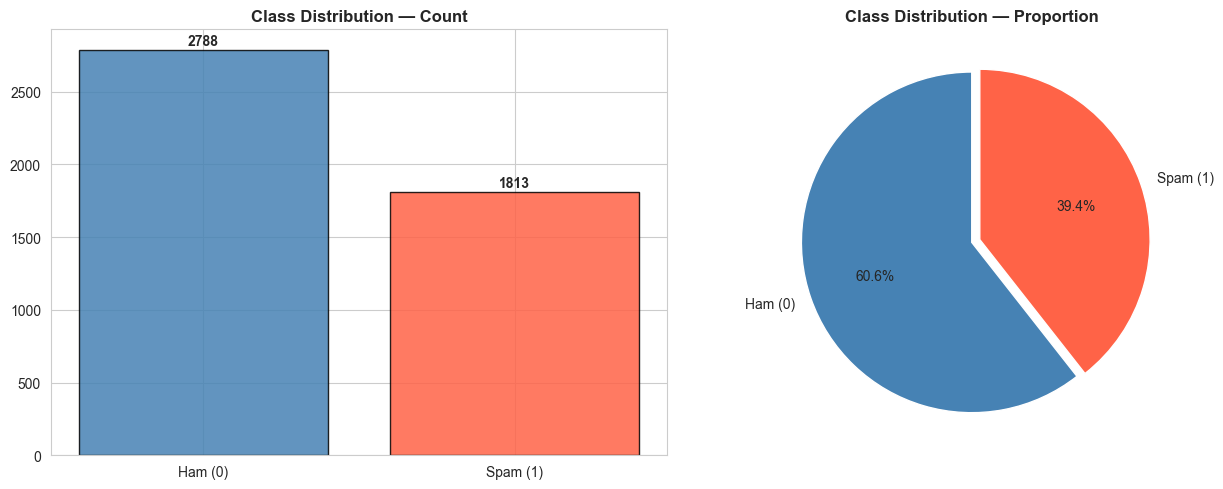

In [18]:
class_counts = df[TARGET].value_counts()
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].bar(['Ham (0)', 'Spam (1)'], class_counts.values,
            color=['steelblue', 'tomato'], edgecolor='black', alpha=0.85)
axes[0].set_title('Class Distribution — Count', fontsize=12, fontweight='bold')
for i, v in enumerate(class_counts.values):
    axes[0].text(i, v + 30, str(v), ha='center', fontweight='bold')

axes[1].pie(class_counts.values, labels=['Ham (0)', 'Spam (1)'],
            colors=['steelblue', 'tomato'], autopct='%1.1f%%',
            startangle=90, explode=[0, 0.05])
axes[1].set_title('Class Distribution — Proportion', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

In [19]:
word_cols = [c for c in features if c.startswith('word_')]
skewness = df[word_cols].skew().sort_values(ascending=False)
print(f'Highly skewed features (skewness > 3): {(skewness > 3).sum()} / {len(word_cols)}')
print(f'Average skewness across word features: {skewness.mean():.2f}')

zero_pct = (df[word_cols] == 0).mean()
print(f'\nFeatures with >90% zeros: {(zero_pct > 0.9).sum()}')

Highly skewed features (skewness > 3): 45 / 48
Average skewness across word features: 9.69

Features with >90% zeros: 19


## 3. Data Cleaning

In [20]:
n_before = df.shape[0]
df.drop_duplicates(inplace=True)
df.reset_index(drop=True, inplace=True)
n_after = df.shape[0]
print(f'Rows before deduplication : {n_before}')
print(f'Rows after  deduplication : {n_after}')
print(f'Duplicates removed        : {n_before - n_after}')

Rows before deduplication : 4601
Rows after  deduplication : 4210
Duplicates removed        : 391


In [21]:
null_counts = df.isnull().sum()
print(f'Total null values: {null_counts.sum()}')
if null_counts.sum() == 0:
    print('No missing values — no imputation required.')

Total null values: 0
No missing values — no imputation required.


## 4. Feature Engineering

Based on the Spambase domain:
- **Spam words**: free, money, credit, 000, business, remove, order, internet, make, etc.
- **Ham words**: hp, hpl, george, 650, lab, labs, meeting, edu, etc.

New features created:
- `spam_word_score` — sum of spam-indicative word frequencies
- `ham_word_score`  — sum of ham-indicative word frequencies
- `spam_ham_ratio`  — ratio of spam to ham word scores
- `char_spam_score` — sum of spam-indicative char frequencies (!, $, #)
- `char_ham_score`  — sum of ham-indicative char frequencies (;, ()
- `capital_ratio`   — total capital letters / average run length
- `word_present_*`  — binary presence indicators for key words
- `word_diversity`  — count of distinct word types present

In [22]:
df_eng = df.copy()

SPAM_WORDS = [
    'word_freq_free', 'word_freq_business', 'word_freq_email', 'word_freq_you',
    'word_freq_credit', 'word_freq_your', 'word_freq_000', 'word_freq_money',
    'word_freq_make', 'word_freq_over', 'word_freq_remove', 'word_freq_internet',
    'word_freq_order', 'word_freq_mail', 'word_freq_addresses', 'word_freq_people',
    'word_freq_report', 'word_freq_font'
]

HAM_WORDS = [
    'word_freq_hp', 'word_freq_hpl', 'word_freq_george', 'word_freq_650',
    'word_freq_lab', 'word_freq_labs', 'word_freq_telnet', 'word_freq_857',
    'word_freq_data', 'word_freq_415', 'word_freq_85', 'word_freq_technology',
    'word_freq_1999', 'word_freq_parts', 'word_freq_pm', 'word_freq_direct',
    'word_freq_cs', 'word_freq_meeting', 'word_freq_original', 'word_freq_project',
    'word_freq_re', 'word_freq_edu', 'word_freq_table', 'word_freq_conference'
]

df_eng['spam_word_score'] = df_eng[SPAM_WORDS].sum(axis=1)
df_eng['ham_word_score']  = df_eng[HAM_WORDS].sum(axis=1)
df_eng['spam_ham_ratio']  = (df_eng['spam_word_score'] + 1e-6) / (df_eng['ham_word_score'] + 1e-6)

print('Cluster features created.')
for col in ['spam_word_score', 'ham_word_score', 'spam_ham_ratio']:
    g = df_eng.groupby(TARGET)[col].mean()
    print(f'  {col:25s} — Ham: {g[0]:.3f}, Spam: {g[1]:.3f}')

Cluster features created.
  spam_word_score           — Ham: 2.618, Spam: 7.333
  ham_word_score            — Ham: 5.060, Spam: 0.365
  spam_ham_ratio            — Ham: 462988.441, Spam: 3699453.294


In [23]:
df_eng['char_spam_score'] = (df_eng['char_freq_exclaim'] +
                             df_eng['char_freq_dollar'] +
                             df_eng['char_freq_hash'])

df_eng['char_ham_score']  = (df_eng['char_freq_semicolon'] +
                             df_eng['char_freq_paren'])

df_eng['capital_ratio']   = (df_eng['capital_run_length_total'] /
                             (df_eng['capital_run_length_average'] + 1e-6))

print('Char / capital features created.')
for col in ['char_spam_score', 'char_ham_score', 'capital_ratio']:
    g = df_eng.groupby(TARGET)[col].mean()
    print(f'  {col:25s} — Ham: {g[0]:.3f}, Spam: {g[1]:.3f}')

Char / capital features created.
  char_spam_score           — Ham: 0.154, Spam: 0.779
  char_ham_score            — Ham: 0.222, Spam: 0.128
  capital_ratio             — Ham: 70.234, Spam: 99.139


In [24]:
KEY_WORDS_BINARY = SPAM_WORDS[:8] + HAM_WORDS[:6]
for col in KEY_WORDS_BINARY:
    new_name = col.replace('word_freq_', 'word_present_')
    df_eng[new_name] = (df_eng[col] > 0).astype(int)

all_word_cols = [c for c in features if c.startswith('word_')]
df_eng['word_diversity'] = (df_eng[all_word_cols] > 0).sum(axis=1)

presence_cols = [c for c in df_eng.columns if c.startswith('word_present_')]
print(f'Binary presence features added : {len(presence_cols)}')
print(f'word_diversity  — Ham mean: {df_eng.groupby(TARGET)["word_diversity"].mean()[0]:.1f}, '
      f'Spam mean: {df_eng.groupby(TARGET)["word_diversity"].mean()[1]:.1f}')

all_features_eng = [c for c in df_eng.columns if c != TARGET]
print(f'\nTotal features after engineering: {len(all_features_eng)}')
print(f'  Original : 57')
print(f'  Added    : {len(all_features_eng) - 57}')

Binary presence features added : 14
word_diversity  — Ham mean: 7.1, Spam mean: 10.1

Total features after engineering: 78
  Original : 57
  Added    : 21


## 5. Correlation of Engineered Features with Target

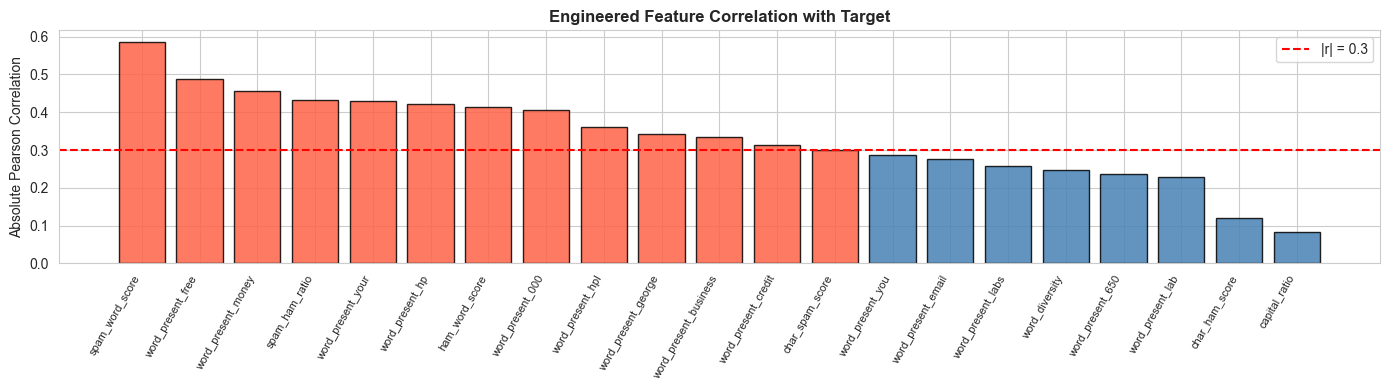

Top engineered features:
spam_word_score        0.587
word_present_free      0.487
word_present_money     0.457
spam_ham_ratio         0.433
word_present_your      0.429
word_present_hp        0.422
ham_word_score         0.414
word_present_000       0.406
word_present_hpl       0.360
word_present_george    0.343


In [25]:
eng_cols = ['spam_word_score', 'ham_word_score', 'spam_ham_ratio',
            'char_spam_score', 'char_ham_score', 'capital_ratio', 'word_diversity'] + presence_cols

corr_with_target = df_eng[eng_cols + [TARGET]].corr()[TARGET].drop(TARGET).abs().sort_values(ascending=False)

plt.figure(figsize=(14, 4))
colors = ['tomato' if v > 0.3 else 'steelblue' for v in corr_with_target.values]
plt.bar(range(len(corr_with_target)), corr_with_target.values, color=colors, edgecolor='black', alpha=0.85)
plt.xticks(range(len(corr_with_target)), corr_with_target.index, rotation=60, ha='right', fontsize=8)
plt.axhline(y=0.3, color='red', linestyle='--', linewidth=1.5, label='|r| = 0.3')
plt.title('Engineered Feature Correlation with Target', fontsize=12, fontweight='bold')
plt.ylabel('Absolute Pearson Correlation')
plt.legend()
plt.tight_layout()
plt.show()

print('Top engineered features:')
print(corr_with_target.head(10).round(3).to_string())

## 6. SMOTE — Balance Classes

In [26]:
X_raw = df_eng.drop(columns=[TARGET])
y_raw = df_eng[TARGET]

print(f'Before SMOTE — Ham: {(y_raw==0).sum()}, Spam: {(y_raw==1).sum()}')

smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_raw, y_raw)

print(f'After  SMOTE — Ham: {(y_resampled==0).sum()}, Spam: {(y_resampled==1).sum()}')
print(f'Total samples after SMOTE: {len(X_resampled)}')

df_final = pd.DataFrame(X_resampled, columns=X_raw.columns)
df_final[TARGET] = y_resampled.values

print(f'\nFinal dataset shape: {df_final.shape}')

Before SMOTE — Ham: 2531, Spam: 1679
After  SMOTE — Ham: 2531, Spam: 2531
Total samples after SMOTE: 5062

Final dataset shape: (5062, 79)


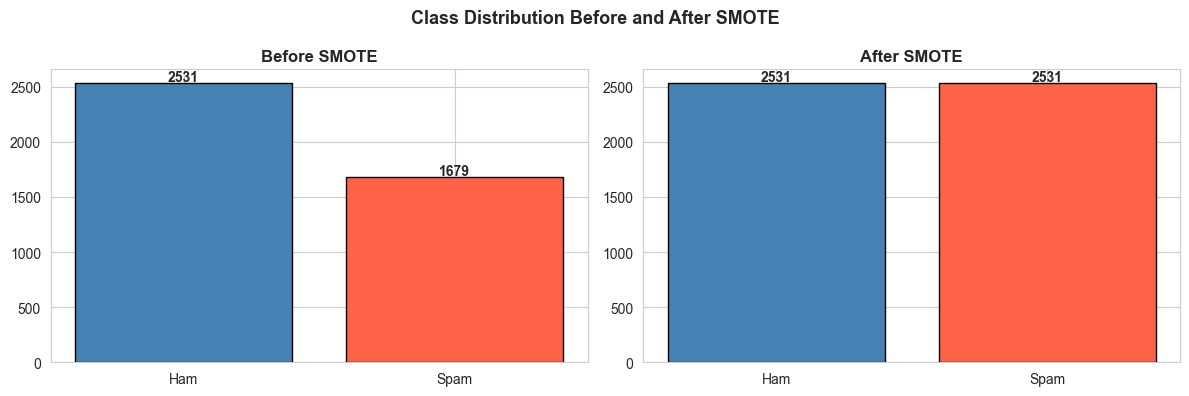

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
before_counts = pd.Series({'Ham': (y_raw==0).sum(), 'Spam': (y_raw==1).sum()})
after_counts  = pd.Series({'Ham': (y_resampled==0).sum(), 'Spam': (y_resampled==1).sum()})

axes[0].bar(before_counts.index, before_counts.values, color=['steelblue', 'tomato'], edgecolor='black')
axes[0].set_title('Before SMOTE', fontsize=12, fontweight='bold')
for i, v in enumerate(before_counts.values):
    axes[0].text(i, v + 20, str(v), ha='center', fontweight='bold')

axes[1].bar(after_counts.index, after_counts.values, color=['steelblue', 'tomato'], edgecolor='black')
axes[1].set_title('After SMOTE', fontsize=12, fontweight='bold')
for i, v in enumerate(after_counts.values):
    axes[1].text(i, v + 20, str(v), ha='center', fontweight='bold')

plt.suptitle('Class Distribution Before and After SMOTE', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 7. Save Preprocessed Data

In [28]:
output_path = 'preprocessed_data_v2.csv'
df_final.to_csv(output_path, index=False)

print(f'Preprocessed data saved to: {output_path}')
print(f'Shape: {df_final.shape}')
print(f'Features: {df_final.shape[1] - 1}')
print(f'  - Original features : 57')
print(f'  - Engineered features: {df_final.shape[1] - 1 - 57}')
print(f'Samples: {df_final.shape[0]} (SMOTE-balanced)')
print(f'\nClass distribution:')
print(df_final[TARGET].value_counts().to_string())
print(f'\nColumn list:')
print([c for c in df_final.columns if c != TARGET])

Preprocessed data saved to: preprocessed_data_v2.csv
Shape: (5062, 79)
Features: 78
  - Original features : 57
  - Engineered features: 21
Samples: 5062 (SMOTE-balanced)

Class distribution:
spam
1    2531
0    2531

Column list:
['word_freq_make', 'word_freq_address', 'word_freq_all', 'word_freq_3d', 'word_freq_our', 'word_freq_over', 'word_freq_remove', 'word_freq_internet', 'word_freq_order', 'word_freq_mail', 'word_freq_receive', 'word_freq_will', 'word_freq_people', 'word_freq_report', 'word_freq_addresses', 'word_freq_free', 'word_freq_business', 'word_freq_email', 'word_freq_you', 'word_freq_credit', 'word_freq_your', 'word_freq_font', 'word_freq_000', 'word_freq_money', 'word_freq_hp', 'word_freq_hpl', 'word_freq_george', 'word_freq_650', 'word_freq_lab', 'word_freq_labs', 'word_freq_telnet', 'word_freq_857', 'word_freq_data', 'word_freq_415', 'word_freq_85', 'word_freq_technology', 'word_freq_1999', 'word_freq_parts', 'word_freq_pm', 'word_freq_direct', 'word_freq_cs', 'word_f